## 🔹 Imports

In [74]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13)

## 🔹 Parâmetros

In [154]:
# Problema
n_vars = 10
bits_var = 14
lower, upper = -5.12, 5.12

# AG
pop_size = 100
max_evaluations = 100000

# Adaptação
Tmax = max_evaluations // pop_size

# Parâmetros para as fórmulas de adaptação
pm0 = 0.05         # Pm alta no início para exploração
pm_min = 0.001    # Pm baixa no fim para estabilidade
pc0  = 0.5        # Pc baixa no início
pc_max  = 0.9     # Pc alta no fim para aproveitar bons genes
alpha = 2       # Coeficiente para a decaimento exponencial (ajustável)


## 🔹 Funções

In [155]:
# ======= Conversão binário para real =============
def bin_to_real(bin_array, lower, upper):
    decimal = int("".join(map(str, bin_array)), 2)
    max_val = 2**len(bin_array) - 1
    return lower + (upper - lower) * decimal / max_val


# ======= Inicialização da população =============
def init_population(pop_size, chromosome_length):
    return np.random.randint(0, 2, (pop_size, chromosome_length))


# ======= Função objetivo (Rastrigin) =============
def rastrigin(x):
    n = len(x)
    return 10*n + sum(xi**2 - 10*np.cos(2*np.pi*xi) for xi in x)


# ======= Decodificação do indivíduo =============
def decode(individual, n_vars, bits_per_var, lower, upper):
    x = []
    for i in range(n_vars):
        start = i * bits_per_var
        end = start + bits_per_var
        xi = bin_to_real(individual[start:end], lower, upper)
        x.append(xi)
    return np.array(x)


# ======= Avaliação da população =============
def evaluate_population(pop, n_vars, bits_per_var, lower, upper):
    fitness = []
    for ind in pop:
        x = decode(ind, n_vars, bits_per_var, lower, upper)
        fitness.append(rastrigin(x))
    return np.array(fitness)


# ======= Seleção mista (torneio + roleta) =============
def mixed_selection(pop, fitness, k=6):
    selected = []
    pop_size = len(pop)

    # Preparação para a Roleta: 
    # Como é minimização, ajusta para que o menor fitness tenha a maior probabilidade e que não tenha problema com divisão por zero
    fitness_adj = np.max(fitness) - fitness + 1e-6
    probs = fitness_adj / np.sum(fitness_adj)

    for _ in range(pop_size):
        # Sorteia 50% de probabilidade para decidir o método
        if np.random.rand() < 0.5:
            # --- Lógica do Torneio ---
            indices = np.random.choice(pop_size, k)
            best = indices[np.argmin(fitness[indices])] 
            selected.append(pop[best])
        else:
            # --- Lógica da Roleta ---
            # Seleciona um índice baseado nas probabilidades calculadas acima
            idx_roulette = np.random.choice(pop_size, p=probs)
            selected.append(pop[idx_roulette])

    return np.array(selected)

# ============ Cruzamento ===================
def crossover(parent1, parent2, pc, n_vars, bits_per_var):
    if np.random.rand() >= pc:
        return parent1.copy(), parent2.copy()
    
    child1 = []
    child2 = []
    for i in range(n_vars):
        start = i * bits_per_var
        end = start + bits_per_var

        p1 = parent1[start:end]
        p2 = parent2[start:end]

        point = np.random.randint(1, bits_per_var)

        c1 = np.concatenate([p1[:point], p2[point:]])
        c2 = np.concatenate([p2[:point], p1[point:]])
        child1.extend(c1)
        child2.extend(c2)

    return np.array(child1), np.array(child2)


# =========== Mutação ===================
def mutation(individual, pm):
    for j in range(len(individual)):
        if np.random.rand() < pm:
            individual[j] = 1 - individual[j]
    return individual


# ======== Probabilidade de mutação dinâmica ===========
def get_dynamic_pm(t, t_max):
    val = pm0 * np.exp(-alpha * (t / t_max))
    return np.clip(val, pm_min, pm0)


# ======= Probabilidade de cruzamento dinâmica ===========
def get_dynamic_pc(t, t_max):
    val = pc0 + (pc_max - pc0) * (t / t_max)
    return np.clip(val, pc0, pc_max) 


## 🔹 Loop principal

In [156]:
def genetic_algorithm():
    pop = init_population(pop_size, n_vars * bits_var)
    total_evals = 0
    generation = 0
    best_history = []
    avg_history = []
    pc_history = []
    pm_history = []

    print(f"Iniciando AG com limite de {max_evaluations} avaliações...")

    while total_evals < max_evaluations:
        # Avaliar
        fitness = evaluate_population(pop, n_vars, bits_var, lower, upper)
        total_evals += pop_size
        
        # Logs e métricas
        best_fit = np.min(fitness)
        avg_fit = np.mean(fitness)
        best_history.append(best_fit)
        avg_history.append(avg_fit)
        
        # Ajuste Dinâmico de Hiperparâmetros
        
        current_pm = get_dynamic_pm(generation, Tmax)
        current_pc = get_dynamic_pc(generation, Tmax)
        pm_history.append(current_pm)
        pc_history.append(current_pc)
        
        # Selecionar (50% Roleta, 50% Torneio)
        selected = mixed_selection(pop, fitness)
            
        # Cruzamento (usando pc_atual)
        offspring = []
        for i in range(0, pop_size, 2):
            c1, c2 = crossover(selected[i], selected[i+1],current_pc , n_vars, bits_var)
            offspring.append(c1)
            offspring.append(c2)
            
        # Mutação (usando pm_atual)
        for i in range(len(offspring)):
            offspring[i] = mutation(offspring[i], current_pm)
            
        # Elitismo: substituir o pior offspring pelo melhor da população atual
        best_idx = np.argmin(fitness)
        best_individual = pop[best_idx]
        offspring = np.array(offspring)
        fitness_offspring = evaluate_population(offspring, n_vars, bits_var, lower, upper)
        worst_idx = np.argmax(fitness_offspring)
        offspring[worst_idx] = best_individual
            
        # Atualizar
        pop = offspring
        
        # Debug print
        if generation % 10 == 0:
            print(f"Gen {generation:4d} | Evals: {total_evals:6d} | Melhor Fitness: {best_fit:.4f} | Pm: {current_pm:.4f} | Pc: {current_pc:.4f}")
        generation += 1
    
    return best_history, avg_history, pm_history, pc_history, pop

## 🔹 Execução e Plots

Iniciando AG com limite de 100000 avaliações...
Gen    0 | Evals:    100 | Melhor Fitness: 120.3342 | Pm: 0.0500 | Pc: 0.5000
Gen   10 | Evals:   1100 | Melhor Fitness: 46.4123 | Pm: 0.0490 | Pc: 0.5040
Gen   20 | Evals:   2100 | Melhor Fitness: 40.7063 | Pm: 0.0480 | Pc: 0.5080
Gen   30 | Evals:   3100 | Melhor Fitness: 31.1219 | Pm: 0.0471 | Pc: 0.5120
Gen   40 | Evals:   4100 | Melhor Fitness: 28.2215 | Pm: 0.0462 | Pc: 0.5160
Gen   50 | Evals:   5100 | Melhor Fitness: 28.2215 | Pm: 0.0452 | Pc: 0.5200
Gen   60 | Evals:   6100 | Melhor Fitness: 24.1483 | Pm: 0.0443 | Pc: 0.5240
Gen   70 | Evals:   7100 | Melhor Fitness: 23.5189 | Pm: 0.0435 | Pc: 0.5280
Gen   80 | Evals:   8100 | Melhor Fitness: 21.8282 | Pm: 0.0426 | Pc: 0.5320
Gen   90 | Evals:   9100 | Melhor Fitness: 21.2811 | Pm: 0.0418 | Pc: 0.5360
Gen  100 | Evals:  10100 | Melhor Fitness: 21.1542 | Pm: 0.0409 | Pc: 0.5400
Gen  110 | Evals:  11100 | Melhor Fitness: 20.6376 | Pm: 0.0401 | Pc: 0.5440
Gen  120 | Evals:  12100 | 

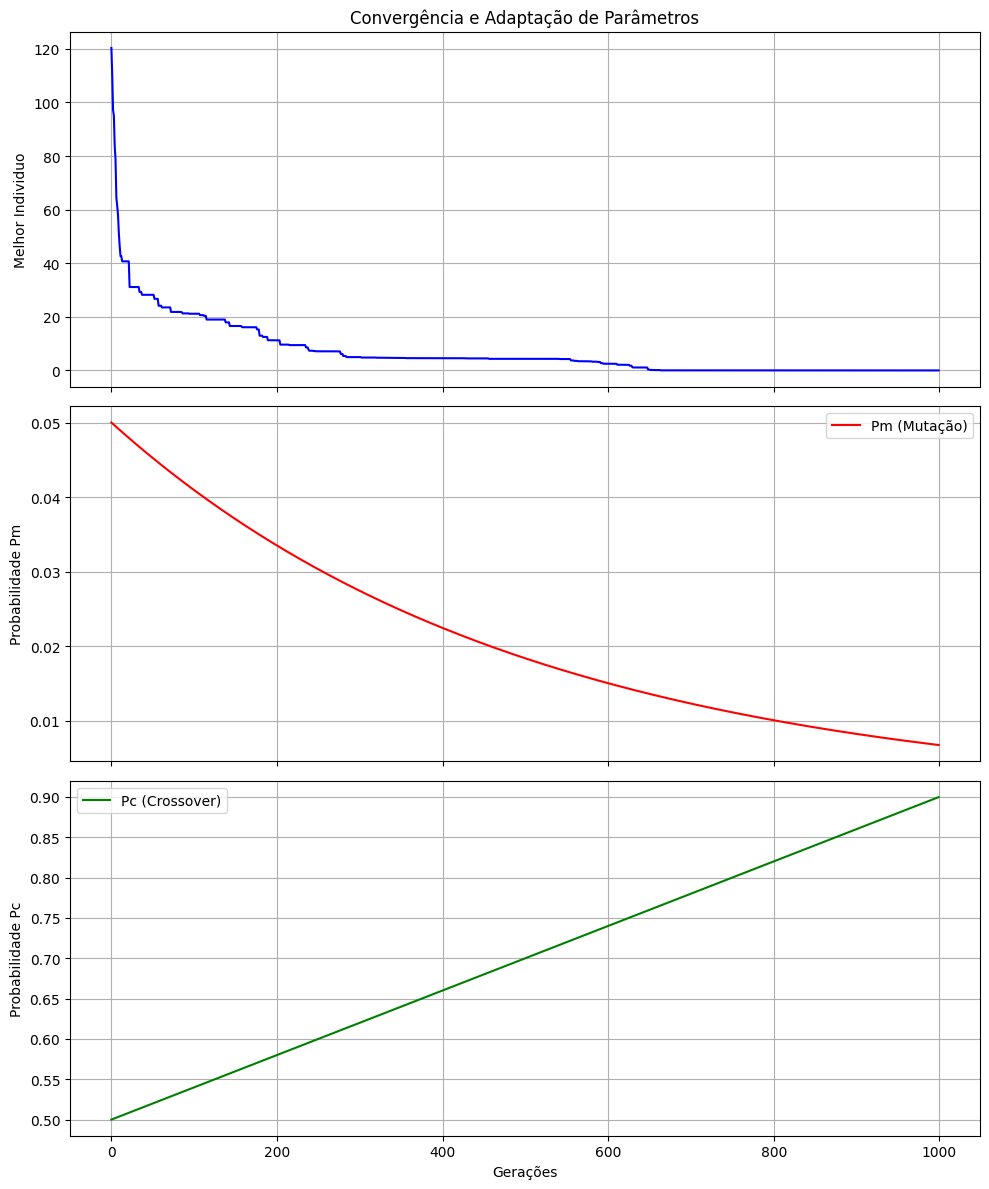

In [157]:
best_hist, avg_hist, pm_hist, pc_hist, final_pop = genetic_algorithm()
fitness_final = evaluate_population(final_pop, n_vars, bits_var, lower, upper)
best_idx = np.argmin(fitness_final)
best_x = decode(final_pop[best_idx], n_vars, bits_var, lower, upper)
print("\n--- FINALIZADO ---")
print(f"Melhor f(x) encontrado: {rastrigin(best_x):.6f}")

# Visualização Tripla
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

ax1.plot(best_hist, color='blue')
ax1.set_ylabel('Melhor Individuo')
ax1.set_title('Convergência e Adaptação de Parâmetros')
ax1.grid(True)

ax2.plot(pm_hist, color='red', label='Pm (Mutação)')
ax2.set_ylabel('Probabilidade Pm')
ax2.legend()
ax2.grid(True)

ax3.plot(pc_hist, color='green', label='Pc (Crossover)')
ax3.set_ylabel('Probabilidade Pc')
ax3.set_xlabel('Gerações')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()